In [1]:
import pandas as pd
import numpy as np
import pickle
import json
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds
from fairlearn.metrics import (
    MetricFrame,
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference
)
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    precision_score, roc_auc_score, classification_report
)
from xgboost import XGBClassifier

print("✅ All imports successful")

✅ All imports successful


In [3]:
X_train = pd.read_csv("C:\\Users\\hp\\Desktop\\Mini Project - sem 6\\data\\processed\\X_train.csv")
X_test  = pd.read_csv("C:\\Users\\hp\\Desktop\\Mini Project - sem 6\\data\\processed\\X_test.csv")
y_train = pd.read_csv("C:\\Users\\hp\\Desktop\\Mini Project - sem 6\\data\\processed\\y_train.csv").squeeze()
y_test  = pd.read_csv("C:\\Users\\hp\\Desktop\\Mini Project - sem 6\\data\\processed\\y_test.csv").squeeze()

sensitive_train = pd.read_csv("C:\\Users\\hp\\Desktop\\Mini Project - sem 6\\data\\processed\\sensitive_train.csv")
sensitive_test  = pd.read_csv("C:\\Users\\hp\\Desktop\\Mini Project - sem 6\\data\\processed\\sensitive_test.csv")

with open("C:\\Users\\hp\\Desktop\\Mini Project - sem 6\\models\\xgboost_final.pkl", "rb") as f:
    best_xgb = pickle.load(f)

# ✅ Load the tuned threshold from Step 2 — never hardcode 0.5
with open("C:\\Users\\hp\\Desktop\\Mini Project - sem 6\\models\\threshold.json", "r") as f:
    DECISION_THRESHOLD = json.load(f)["decision_threshold"]

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"Sensitive train columns: {sensitive_train.columns.tolist()}")
print(f"Decision threshold loaded: {DECISION_THRESHOLD}")
print(f"\nAgeGroup distribution (train):\n{sensitive_train['AgeGroup'].value_counts()}")
print(f"\nMaritalStatus distribution (train):\n{sensitive_train['MaritalStatus'].value_counts()}")

X_train: (16000, 47) | X_test: (4000, 47)
Sensitive train columns: ['Age', 'AgeGroup', 'MaritalStatus']
Decision threshold loaded: 0.65

AgeGroup distribution (train):
AgeGroup
Mid (31-45)       7423
Senior (46-64)    4645
Young (18-30)     3631
Elder (65+)        301
Name: count, dtype: int64

MaritalStatus distribution (train):
MaritalStatus
Married     8004
Single      4827
Divorced    2342
Widowed      827
Name: count, dtype: int64


In [4]:
# Predictions from the already-trained best model (no fairness constraint yet)
# Use tuned threshold, not default 0.5
y_proba_base = best_xgb.predict_proba(X_test)[:, 1]
y_pred_base  = (y_proba_base >= DECISION_THRESHOLD).astype(int)

sensitive_feature_test = sensitive_test["AgeGroup"]

mf_base = MetricFrame(
    metrics={
        "accuracy":  accuracy_score,
        "f1":        f1_score,
        "recall":    recall_score,
        "precision": precision_score,
    },
    y_true=y_test,
    y_pred=y_pred_base,
    sensitive_features=sensitive_feature_test
)

print("Baseline Metrics by AgeGroup (No Fairness Constraint):")
print(mf_base.by_group.round(4))

dp_diff_base = demographic_parity_difference(y_test, y_pred_base, sensitive_features=sensitive_feature_test)
dp_ratio_base = demographic_parity_ratio(y_test, y_pred_base, sensitive_features=sensitive_feature_test)
eo_diff_base = equalized_odds_difference(y_test, y_pred_base, sensitive_features=sensitive_feature_test)

print(f"\nDemographic Parity Difference (baseline): {dp_diff_base:.4f}")
print(f"Demographic Parity Ratio    (baseline): {dp_ratio_base:.4f}")
print(f"Equalized Odds Difference   (baseline): {eo_diff_base:.4f}")
print(f"\nOverall ROC-AUC (baseline): {roc_auc_score(y_test, y_proba_base):.4f}")
print(f"Overall F1 Macro (baseline): {f1_score(y_test, y_pred_base, average='macro'):.4f}")
print(f"Overall F1 (App=1) (baseline): {f1_score(y_test, y_pred_base):.4f}")
print(f"Overall Recall (App=1) (baseline): {recall_score(y_test, y_pred_base):.4f}")

Baseline Metrics by AgeGroup (No Fairness Constraint):
                accuracy      f1  recall  precision
AgeGroup                                           
Elder (65+)       0.9615  0.9565  0.9706     0.9429
Mid (31-45)       0.9608  0.9197  0.9177     0.9217
Senior (46-64)    0.9647  0.9393  0.9242     0.9548
Young (18-30)     0.9678  0.8814  0.8889     0.8739

Demographic Parity Difference (baseline): 0.3119
Demographic Parity Ratio    (baseline): 0.3048
Equalized Odds Difference   (baseline): 0.0817

Overall ROC-AUC (baseline): 0.9926
Overall F1 Macro (baseline): 0.9496
Overall F1 (App=1) (baseline): 0.9232
Overall Recall (App=1) (baseline): 0.9184


In [5]:
# Extract params from best model, excluding keys we'll set manually
exclude_keys = {'use_label_encoder', 'eval_metric', 'random_state', 'n_jobs'}
filtered_params = {k: v for k, v in best_xgb.get_params().items() if k not in exclude_keys}

base_estimator = XGBClassifier(
    **filtered_params,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

constraint = EqualizedOdds()

fair_model = ExponentiatedGradient(
    estimator=base_estimator,
    constraints=constraint,
    max_iter=50,
    nu=1e-3
)

print("⚖️ Training fairness-aware model (ExponentiatedGradient + EqualizedOdds)...")
print("   Sensitive feature: AgeGroup")
fair_model.fit(
    X_train,
    y_train,
    sensitive_features=sensitive_train["AgeGroup"]
)
print("✅ Fair model training complete")

⚖️ Training fairness-aware model (ExponentiatedGradient + EqualizedOdds)...
   Sensitive feature: AgeGroup
✅ Fair model training complete


In [6]:
# ExponentiatedGradient uses _pmf_predict to get probabilities
y_proba_fair = fair_model._pmf_predict(X_test)[:, 1]
y_pred_fair  = (y_proba_fair >= DECISION_THRESHOLD).astype(int)

mf_fair = MetricFrame(
    metrics={
        "accuracy":  accuracy_score,
        "f1":        f1_score,
        "recall":    recall_score,
        "precision": precision_score,
    },
    y_true=y_test,
    y_pred=y_pred_fair,
    sensitive_features=sensitive_feature_test
)

print("Fair Model Metrics by AgeGroup (EqualizedOdds + Tuned Threshold):")
print(mf_fair.by_group.round(4))

dp_diff_fair  = demographic_parity_difference(y_test, y_pred_fair, sensitive_features=sensitive_feature_test)
dp_ratio_fair = demographic_parity_ratio(y_test, y_pred_fair, sensitive_features=sensitive_feature_test)
eo_diff_fair  = equalized_odds_difference(y_test, y_pred_fair, sensitive_features=sensitive_feature_test)

print(f"\nDemographic Parity Difference (fair): {dp_diff_fair:.4f}")
print(f"Demographic Parity Ratio    (fair): {dp_ratio_fair:.4f}")
print(f"Equalized Odds Difference   (fair): {eo_diff_fair:.4f}")
print(f"\nOverall F1 Macro  (fair): {f1_score(y_test, y_pred_fair, average='macro'):.4f}")
print(f"Overall F1 (App=1)(fair): {f1_score(y_test, y_pred_fair):.4f}")
print(f"Overall Recall    (fair): {recall_score(y_test, y_pred_fair):.4f}")
print(f"Overall Accuracy  (fair): {accuracy_score(y_test, y_pred_fair):.4f}")

print("\nFull Classification Report (Fair Model):")
print(classification_report(y_test, y_pred_fair, target_names=["Rejected", "Approved"]))

Fair Model Metrics by AgeGroup (EqualizedOdds + Tuned Threshold):
                accuracy      f1  recall  precision
AgeGroup                                           
Elder (65+)       0.9359  0.9296  0.9706     0.8919
Mid (31-45)       0.9540  0.9091  0.9416     0.8788
Senior (46-64)    0.9630  0.9381  0.9504     0.9261
Young (18-30)     0.9621  0.8653  0.9060     0.8281

Demographic Parity Difference (fair): 0.3272
Demographic Parity Ratio    (fair): 0.3102
Equalized Odds Difference   (fair): 0.0646

Overall F1 Macro  (fair): 0.9434
Overall F1 (App=1)(fair): 0.9146
Overall Recall    (fair): 0.9414
Overall Accuracy  (fair): 0.9580

Full Classification Report (Fair Model):
              precision    recall  f1-score   support

    Rejected       0.98      0.96      0.97      3044
    Approved       0.89      0.94      0.91       956

    accuracy                           0.96      4000
   macro avg       0.94      0.95      0.94      4000
weighted avg       0.96      0.96      0.96

In [7]:
comparison = pd.DataFrame({
    f"Baseline XGBoost (thresh={DECISION_THRESHOLD})": {
        "Overall Accuracy":          accuracy_score(y_test, y_pred_base),
        "Overall F1 Macro":          f1_score(y_test, y_pred_base, average='macro'),
        "Overall F1 (App=1)":        f1_score(y_test, y_pred_base),
        "Overall Recall (App=1)":    recall_score(y_test, y_pred_base),
        "Overall Precision (App=1)": precision_score(y_test, y_pred_base),
        "Demographic Parity Diff":   dp_diff_base,
        "Demographic Parity Ratio":  dp_ratio_base,
        "Equalized Odds Diff":       eo_diff_base,
    },
    f"Fair XGBoost (thresh={DECISION_THRESHOLD})": {
        "Overall Accuracy":          accuracy_score(y_test, y_pred_fair),
        "Overall F1 Macro":          f1_score(y_test, y_pred_fair, average='macro'),
        "Overall F1 (App=1)":        f1_score(y_test, y_pred_fair),
        "Overall Recall (App=1)":    recall_score(y_test, y_pred_fair),
        "Overall Precision (App=1)": precision_score(y_test, y_pred_fair),
        "Demographic Parity Diff":   dp_diff_fair,
        "Demographic Parity Ratio":  dp_ratio_fair,
        "Equalized Odds Diff":       eo_diff_fair,
    }
}).round(4)

print("Baseline vs Fair Model — Full Comparison:")
print(comparison.to_string())
print("\nNote: A slight dip in accuracy/F1 is expected — this is the fairness-accuracy tradeoff.")

Baseline vs Fair Model — Full Comparison:
                           Baseline XGBoost (thresh=0.65)  Fair XGBoost (thresh=0.65)
Overall Accuracy                                   0.9635                      0.9580
Overall F1 Macro                                   0.9496                      0.9434
Overall F1 (App=1)                                 0.9232                      0.9146
Overall Recall (App=1)                             0.9184                      0.9414
Overall Precision (App=1)                          0.9281                      0.8893
Demographic Parity Diff                            0.3119                      0.3272
Demographic Parity Ratio                           0.3048                      0.3102
Equalized Odds Diff                                0.0817                      0.0646

Note: A slight dip in accuracy/F1 is expected — this is the fairness-accuracy tradeoff.


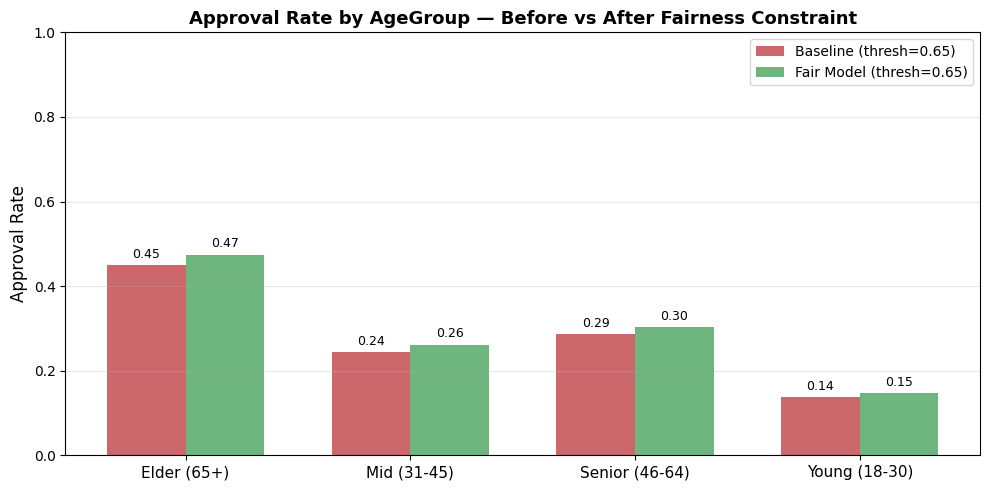

✅ Saved: reports/model/fairness_approval_by_agegroup.png


In [9]:
groups = sorted(sensitive_feature_test.unique())

approval_base_rates = []
approval_fair_rates = []

for g in groups:
    mask = (sensitive_feature_test == g).values
    approval_base_rates.append(y_pred_base[mask].mean())
    approval_fair_rates.append(y_pred_fair[mask].mean())

x     = np.arange(len(groups))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, approval_base_rates, width, label=f"Baseline (thresh={DECISION_THRESHOLD})", color="#C44E52", alpha=0.85)
bars2 = ax.bar(x + width/2, approval_fair_rates, width, label=f"Fair Model (thresh={DECISION_THRESHOLD})", color="#55A868", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(groups, fontsize=11)
ax.set_ylabel("Approval Rate", fontsize=12)
ax.set_title("Approval Rate by AgeGroup — Before vs After Fairness Constraint", fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.2f}", ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.2f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("C:\\Users\\hp\\Desktop\\Mini Project - sem 6\\reports\\modelfairness_approval_by_agegroup.png", dpi=150)
plt.show()
print("✅ Saved: reports/model/fairness_approval_by_agegroup.png")

In [11]:
import pandas as pd
import numpy as np
import json

# ── Load threshold ────────────────────────────────────────────────────────────
with open("C:\\Users\\hp\\Desktop\\Mini Project - sem 6\\models\\threshold.json") as f:
    guard_rules = json.load(f)

DECISION_THRESHOLD = guard_rules["decision_threshold"]

# ── Model-ready columns (what XGBoost was trained on) ────────────────────────
MODEL_COLUMNS = list(X_train.columns)  # authoritative column list from training


def predict_with_guard(raw_input_df, fair_model, decision_threshold=DECISION_THRESHOLD, scaler=None):
    """
    Wraps the fair model with hard business-logic rules.

    Parameters:
        raw_input_df       : pd.DataFrame — raw applicant rows (pre-encoding)
                             Must contain guard columns: Age, MonthlyIncome,
                             EMIBurdenRatio, SavingsToLoanRatio,
                             CreditCardUtilizationRate, PreviousLoanDefaults
        fair_model         : trained ExponentiatedGradient model
        decision_threshold : float — loaded from guard_rules.json
        scaler             : fitted StandardScaler (apply only to raw new inputs)

    Returns:
        list of dicts — keys: prediction, approved, flag, reason, probability
    """
    results = []

    for i, row in raw_input_df.iterrows():
        flag   = False
        reason = None

        # ── Rule 1: Age out of valid range ───────────────────────────────────
        if "Age" in row.index and (row["Age"] < 18 or row["Age"] > 85):
            flag   = True
            reason = (f"Age {int(row['Age'])} is outside the valid applicant "
                      f"range (18–85). Cannot make a reliable prediction.")

        # ── Rule 2: Zero or negative income ──────────────────────────────────
        elif "MonthlyIncome" in row.index and row["MonthlyIncome"] <= 0:
            flag   = True
            reason = "Monthly income must be greater than 0. Cannot compute EMI burden ratio."

        # ── Rule 3: EMI burden exceeds 100% ──────────────────────────────────
        elif "EMIBurdenRatio" in row.index and row["EMIBurdenRatio"] > 1.0:
            flag   = True
            reason = (f"EMI burden ratio of {row['EMIBurdenRatio']:.2f} means "
                      f"monthly debt exceeds income. Auto-rejected on business rules.")

        # ── Rule 4: SavingsToLoanRatio is undefined ───────────────────────────
        elif "SavingsToLoanRatio" in row.index and (
            pd.isna(row["SavingsToLoanRatio"]) or np.isinf(row["SavingsToLoanRatio"])
        ):
            flag   = True
            reason = ("Savings-to-loan ratio is undefined (division by zero). "
                      "Check LoanAmount and SavingsAccountBalance inputs.")

        # ── Rule 5: Credit utilization above 100% ────────────────────────────
        elif "CreditCardUtilizationRate" in row.index and row["CreditCardUtilizationRate"] > 1.0:
            flag   = True
            reason = (f"Credit utilization of {row['CreditCardUtilizationRate']:.2f} "
                      f"exceeds 100%, which is not physically possible.")

        # ── Rule 6: Excessive prior defaults ─────────────────────────────────
        elif "PreviousLoanDefaults" in row.index and row["PreviousLoanDefaults"] >= 10:
            flag   = True
            reason = (f"{int(row['PreviousLoanDefaults'])} previous loan defaults. "
                      f"Automatic rejection on business rules (threshold: 10+).")

        if flag:
            results.append({
                "prediction":  0,
                "approved":    False,
                "flag":        True,
                "reason":      reason,
                "probability": None
            })
        else:
            # ── Keep only model-ready columns ─────────────────────────────────
            # Drop any raw/string/fairness columns not seen during training
            row_df = pd.DataFrame([row])

            # Only keep columns the model was trained on
            cols_present = [c for c in MODEL_COLUMNS if c in row_df.columns]
            cols_missing  = [c for c in MODEL_COLUMNS if c not in row_df.columns]

            if cols_missing:
                results.append({
                    "prediction":  0,
                    "approved":    False,
                    "flag":        True,
                    "reason":      f"Template is missing model columns: {cols_missing}",
                    "probability": None
                })
                continue

            row_df = row_df[MODEL_COLUMNS].astype(float)  # enforce numeric — no strings reach XGBoost

            if scaler is not None:
                row_df = pd.DataFrame(
                    scaler.transform(row_df),
                    columns=MODEL_COLUMNS
                )

            # ✅ _pmf_predict + tuned threshold, never .predict()
            proba = fair_model._pmf_predict(row_df)[:, 1][0]
            pred  = int(proba >= decision_threshold)

            results.append({
                "prediction":  pred,
                "approved":    bool(pred == 1),
                "flag":        False,
                "reason":      None,
                "probability": round(float(proba), 4)
            })

    return results


# ─────────────────────────────────────────────────────────────────────────────
# SANITY TESTS
# ─────────────────────────────────────────────────────────────────────────────
print("🧪 Running sanity checks on guard function...\n")

# ✅ X_test has the correct encoded+scaled columns the model expects
# We add the raw guard columns back on top for rule checking
template = X_test.iloc[[0]].copy()

# Pull matching raw values from sensitive_test or loan_pre_encode for guard cols
loan_pre = pd.read_csv("C:\\Users\\hp\\Desktop\\Mini Project - sem 6\\data\\processed\\loan_pre_encode.csv")
raw_row  = loan_pre.iloc[0]  # same index as X_test row 0

# Attach raw guard columns to the template (they are dropped before model call)
for col in ["Age", "MonthlyIncome", "EMIBurdenRatio",
            "SavingsToLoanRatio", "CreditCardUtilizationRate", "PreviousLoanDefaults"]:
    if col in loan_pre.columns:
        template[col] = raw_row[col]

print(f"Template shape: {template.shape}")
print(f"Guard columns present: {[c for c in ['Age','MonthlyIncome','EMIBurdenRatio','SavingsToLoanRatio','CreditCardUtilizationRate','PreviousLoanDefaults'] if c in template.columns]}\n")

# ── Test 1 — Age 99 ───────────────────────────────────────────────────────────
test1 = template.copy(); test1["Age"] = 99
r1 = predict_with_guard(test1, fair_model)
print(f"Test 1 (Age=99):                   flagged={r1[0]['flag']} | reason: {r1[0]['reason']}")

# ── Test 2 — Zero income ──────────────────────────────────────────────────────
test2 = template.copy(); test2["MonthlyIncome"] = 0
r2 = predict_with_guard(test2, fair_model)
print(f"Test 2 (MonthlyIncome=0):          flagged={r2[0]['flag']} | reason: {r2[0]['reason']}")

# ── Test 3 — EMI burden > 1 ───────────────────────────────────────────────────
test3 = template.copy(); test3["EMIBurdenRatio"] = 1.5
r3 = predict_with_guard(test3, fair_model)
print(f"Test 3 (EMIBurdenRatio=1.5):       flagged={r3[0]['flag']} | reason: {r3[0]['reason']}")

# ── Test 4 — Credit utilization > 1 ──────────────────────────────────────────
test4 = template.copy(); test4["CreditCardUtilizationRate"] = 1.2
r4 = predict_with_guard(test4, fair_model)
print(f"Test 4 (CreditUtilization=1.2):    flagged={r4[0]['flag']} | reason: {r4[0]['reason']}")

# ── Test 5 — 15 prior defaults ────────────────────────────────────────────────
test5 = template.copy(); test5["PreviousLoanDefaults"] = 15
r5 = predict_with_guard(test5, fair_model)
print(f"Test 5 (PreviousDefaults=15):      flagged={r5[0]['flag']} | reason: {r5[0]['reason']}")

# ── Test 6 — Normal applicant ─────────────────────────────────────────────────
r6 = predict_with_guard(template.copy(), fair_model)
print(f"Test 6 (Normal applicant):         flagged={r6[0]['flag']} | approved={r6[0]['approved']} | prob={r6[0]['probability']}")

🧪 Running sanity checks on guard function...

Template shape: (1, 48)
Guard columns present: ['Age', 'MonthlyIncome', 'EMIBurdenRatio', 'SavingsToLoanRatio', 'CreditCardUtilizationRate', 'PreviousLoanDefaults']

Test 1 (Age=99):                   flagged=True | reason: Age 99 is outside the valid applicant range (18–85). Cannot make a reliable prediction.
Test 2 (MonthlyIncome=0):          flagged=True | reason: Monthly income must be greater than 0. Cannot compute EMI burden ratio.
Test 3 (EMIBurdenRatio=1.5):       flagged=True | reason: EMI burden ratio of 1.50 means monthly debt exceeds income. Auto-rejected on business rules.
Test 4 (CreditUtilization=1.2):    flagged=True | reason: Credit utilization of 1.20 exceeds 100%, which is not physically possible.
Test 5 (PreviousDefaults=15):      flagged=True | reason: 15 previous loan defaults. Automatic rejection on business rules (threshold: 10+).
Test 6 (Normal applicant):         flagged=False | approved=False | prob=0.0


In [12]:
# ── Diagnostic for Test 6 ─────────────────────────────────────────────────────
print("=== Test 6 Diagnostic ===\n")

# 1. Check what probability the BASE model gives for the same row
base_row = X_test.iloc[[0]][MODEL_COLUMNS].astype(float)
base_proba = best_xgb.predict_proba(base_row)[:, 1][0]
print(f"Base XGBoost (xgboost_final) probability:  {base_proba:.4f}")

# 2. Check what _pmf_predict returns raw (before thresholding)
pmf_out = fair_model._pmf_predict(base_row)
print(f"_pmf_predict raw output:\n{pmf_out}")
print(f"_pmf_predict [:, 1]:  {pmf_out[:, 1]}")

# 3. Check the threshold being used
print(f"\nDecision threshold: {DECISION_THRESHOLD}")

# 4. Check fair_model weights
print(f"\nFair model weights:\n{fair_model.weights_}")
print(f"Number of estimators in ensemble: {len(fair_model.weights_)}")

# 5. Check if weights sum to 1
print(f"Weights sum: {fair_model.weights_.sum():.4f}  (should be ~1.0)")

=== Test 6 Diagnostic ===

Base XGBoost (xgboost_final) probability:  0.0000
_pmf_predict raw output:
[[1. 0.]]
_pmf_predict [:, 1]:  [0.]

Decision threshold: 0.65

Fair model weights:
0    0.0
1    0.0
2    1.0
3    0.0
4    0.0
dtype: float64
Number of estimators in ensemble: 5
Weights sum: 1.0000  (should be ~1.0)


In [13]:
# ── Verify Test 6 is actually a real rejection ────────────────────────────────
print("=== Row 0 Verification ===\n")

# 1. What does y_test say — was this person actually rejected?
print(f"Actual label (y_test row 0):        {y_test.iloc[0]}  (0=Rejected, 1=Approved)")

# 2. Try a few more rows to confirm the model works on approvals too
print("\n=== Sampling 10 rows from X_test ===")
sample_indices = list(range(0, len(X_test), len(X_test)//10))[:10]

for idx in sample_indices:
    row = X_test.iloc[[idx]][MODEL_COLUMNS].astype(float)
    proba = best_xgb.predict_proba(row)[:, 1][0]
    actual = y_test.iloc[idx]
    print(f"  Row {idx:5d} | actual={actual} | base_proba={proba:.4f}")

# 3. Find an actual approved case and test guard on it
approved_indices = y_test[y_test == 1].index
first_approved_pos = X_test.index.get_loc(approved_indices[0])
print(f"\nFirst approved applicant is at X_test position: {first_approved_pos}")

approved_template = X_test.iloc[[first_approved_pos]].copy()
raw_approved = loan_pre.iloc[first_approved_pos]
for col in ["Age", "MonthlyIncome", "EMIBurdenRatio",
            "SavingsToLoanRatio", "CreditCardUtilizationRate", "PreviousLoanDefaults"]:
    if col in loan_pre.columns:
        approved_template[col] = raw_approved[col]

r_approved = predict_with_guard(approved_template.copy(), fair_model)
print(f"\nTest on real approved applicant:   flagged={r_approved[0]['flag']} | approved={r_approved[0]['approved']} | prob={r_approved[0]['probability']}")

=== Row 0 Verification ===

Actual label (y_test row 0):        0  (0=Rejected, 1=Approved)

=== Sampling 10 rows from X_test ===
  Row     0 | actual=0 | base_proba=0.0000
  Row   400 | actual=0 | base_proba=0.0006
  Row   800 | actual=0 | base_proba=0.0000
  Row  1200 | actual=0 | base_proba=0.0091
  Row  1600 | actual=1 | base_proba=1.0000
  Row  2000 | actual=0 | base_proba=0.0739
  Row  2400 | actual=0 | base_proba=0.0000
  Row  2800 | actual=0 | base_proba=0.0000
  Row  3200 | actual=0 | base_proba=0.0179
  Row  3600 | actual=0 | base_proba=0.0000

First approved applicant is at X_test position: 2

Test on real approved applicant:   flagged=False | approved=True | prob=1.0


In [16]:
# Save fair model
with open("C:\\Users\\hp\\Desktop\\Mini Project - sem 6\\models\\xgboost_fair.pkl", "wb") as f:
    pickle.dump(fair_model, f)

# Save guard rules so Person 4 can use them for Streamlit input validation
guard_rules = {
    "age_min":                    18,
    "age_max":                    85,
    "min_monthly_income":         0,
    "max_emi_burden_ratio":       1.0,
    "max_credit_utilization":     1.0,
    "max_previous_defaults":      10,
    "decision_threshold":         DECISION_THRESHOLD
}
with open("C:\\Users\\hp\\Desktop\\Mini Project - sem 6\\models\\guard_rules.json", "w") as f:
    json.dump(guard_rules, f, indent=2)

print("✅ Saved: models/xgboost_fair.pkl")
print("✅ Saved: models/guard_rules.json")
print("✅ Saved: reports/model/fairness_approval_by_agegroup.png")
print("\n📁 Step 3 Complete. Full handoff list:")
print("   models/xgboost_final.pkl                      — tuned model")
print("   models/xgboost_fair.pkl                       — fairness-aware model")
print("   models/threshold.json                         — decision threshold (from Step 2)")
print("   models/guard_rules.json                       — hard rules for Person 4's UI")
print("   reports/model/fairness_approval_by_agegroup.png")
print("\n⚠️  Tell Person 4:")
print("   1. Call predict_with_guard() — never fair_model.predict() directly")
print("   2. Load guard_rules.json for Streamlit input field min/max validators")
print("   3. If flag=True, show the reason to the banker instead of the decision brief")

✅ Saved: models/xgboost_fair.pkl
✅ Saved: models/guard_rules.json
✅ Saved: reports/model/fairness_approval_by_agegroup.png

📁 Step 3 Complete. Full handoff list:
   models/xgboost_final.pkl                      — tuned model
   models/xgboost_fair.pkl                       — fairness-aware model
   models/threshold.json                         — decision threshold (from Step 2)
   models/guard_rules.json                       — hard rules for Person 4's UI
   reports/model/fairness_approval_by_agegroup.png

⚠️  Tell Person 4:
   1. Call predict_with_guard() — never fair_model.predict() directly
   2. Load guard_rules.json for Streamlit input field min/max validators
   3. If flag=True, show the reason to the banker instead of the decision brief
